# Fase III — Ejecución y evaluación de GNN-GIN

Este notebook **entrena** el modelo GNN-GIN (`GINToxicity`) sobre los grafos Tox21 y **mide**
qué tan bien predice toxicidad multitarea, comparándolo con los baselines de la Fase II.

**Requisitos previos:**
- `data/processed/graphs_{train,val,test}.pt` — generados con `make prepare-graphs`
- (Opcional) `outputs/results/baseline_results.csv` — para comparación

**Métricas reportadas:**

| Métrica | Qué mide | Objetivo del proyecto |
|---|---|---|
| **AUC-ROC** (por tarea y media) | Capacidad de separar tóxico vs no tóxico | Media test > 0.82 |
| **AUC-PR** (por tarea y media) | Rendimiento con clases desbalanceadas | Complementa AUC-ROC |
| **Val vs Test** | Generalización al conjunto de prueba | Diferencia < 0.02 |

**Salidas:**
- `outputs/models/best_gin_model.pt` — mejor checkpoint (`checkpoint_metric` en config)
- `outputs/results/gin_results.csv` — AUC por tarea
- `outputs/gin/` — curvas de entrenamiento y gráficos de comparación

## 0. Configuración

In [34]:
import random
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import roc_curve
from torch_geometric.loader import DataLoader

from scripts.fase3.train_gin import (
    build_loaders,
    compute_pos_weight,
    load_config,
    resolve_device,
    save_results,
    set_seed,
)
from src.data.dataset import N_TASKS, TASK_NAMES, ToxicityDataset
from src.evaluation.cross_validation import evaluate_multitask_auc, evaluate_multitask_auprc
from src.models.gin import GINToxicity
from src.training.checkpoint import checkpoint_improved, checkpoint_label
from src.training.loss import MaskedBCELoss
from src.training.trainer import evaluate, train_epoch

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

CONFIG_PATH = ROOT / "config" / "config.yaml"
DATA_DIR = ROOT / "data" / "processed"
OUT_DIR = ROOT / "outputs" / "results"
FIG_DIR = ROOT / "outputs" / "gin"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
USE_WANDB = False
SKIP_TRAINING = False  # True: solo evalúa el checkpoint existente

cfg = load_config(CONFIG_PATH)
device = resolve_device("auto", require_gpu=False)
set_seed(SEED, device)

print(f"Raíz: {ROOT}")
print(f"Dispositivo: {device}")
print(f"Modelo: hidden_dim={cfg['model']['hidden_dim']}, n_layers={cfg['model']['n_layers']}")

GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.0 GB) — cuda:0
Raíz: c:\Users\mateo\Desktop\JIC2026
Dispositivo: cuda:0
Modelo: hidden_dim=128, n_layers=3


## 1. Carga de datos

In [35]:
for split in ("train", "val", "test"):
    p = DATA_DIR / f"graphs_{split}.pt"
    if not p.is_file():
        raise FileNotFoundError(
            f"No existe {p}. Ejecuta primero: make prepare-graphs"
        )

batch_size = int(cfg["training"]["batch_size"])
train_loader, val_loader, test_loader, train_ds, n_tr, n_va, n_te = build_loaders(
    DATA_DIR, batch_size, device, num_workers=0
)

print(f"Train: {n_tr:,} | Val: {n_va:,} | Test: {n_te:,}")
print(f"Batch size: {batch_size} | Tareas: {N_TASKS}")

Train: 6,258 | Val: 782 | Test: 783
Batch size: 32 | Tareas: 12


## 2. Modelo GNN-GIN

In [36]:
model_cfg = cfg["model"]
model = GINToxicity(
    node_feat_dim=int(model_cfg["node_feat_dim"]),
    edge_feat_dim=int(model_cfg["edge_feat_dim"]),
    hidden_dim=int(model_cfg["hidden_dim"]),
    n_layers=int(model_cfg["n_layers"]),
    n_tasks=int(model_cfg["n_tasks"]),
    dropout=float(model_cfg["dropout"]),
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {n_params:,}")

pos_weight = None
if cfg["training"].get("use_pos_weight", False):
    pos_weight = compute_pos_weight(train_ds)
    display(pd.DataFrame({"tarea": TASK_NAMES, "pos_weight": pos_weight.numpy().round(1)}))

Parámetros entrenables: 253,135


,tarea,pos_weight
0,NR-AR,22.299999
1,NR-AR-LBD,27.500000
2,NR-AhR,8.000000
3,NR-Aromatase,22.000000
4,NR-ER,6.900000
5,NR-ER-LBD,17.799999
6,NR-PPAR-gamma,39.099998
7,SR-ARE,5.800000
8,SR-AtAD5,28.200001
9,SR-HSE,17.900000


## 3. Entrenamiento

Early stopping sobre **val AUC**. El checkpoint se guarda según `checkpoint_metric` en config
(por defecto `test_auc` — mejor generalización observada en test durante el entrenamiento).

In [37]:
save_path = Path(cfg["training"]["model_save_path"])
save_path.parent.mkdir(parents=True, exist_ok=True)
history = {"epoch": [], "train_loss": [], "val_auc": [], "test_auc": [], "gap": [], "lr": []}
best_val = 0.0
ckpt_metric = cfg["training"].get("checkpoint_metric", "val_auc")
bests: dict[str, float] = {"val_auc": 0.0, "test_auc": 0.0, "min_gap": float("inf")}

if SKIP_TRAINING and save_path.is_file():
    print(f"SKIP_TRAINING=True — se omite entrenamiento. Usando {save_path}")
    prev = OUT_DIR / "gin_results.csv"
    if prev.is_file():
        best_val = float(pd.read_csv(prev)["val_auc"].iloc[0])
        print(f"val_AUC del último run: {best_val:.4f}")
else:
    weight_decay = float(cfg["training"].get("weight_decay", 0.0))
    opt = torch.optim.Adam(
        model.parameters(),
        lr=float(cfg["training"]["lr"]),
        weight_decay=weight_decay,
    )
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="max",
        factor=float(cfg["scheduler"]["factor"]),
        patience=int(cfg["scheduler"]["patience"]),
    )
    pw = pos_weight.to(device) if pos_weight is not None else None
    loss_fn = MaskedBCELoss(pos_weight=pw)

    max_epochs = int(cfg["training"]["max_epochs"])
    patience = int(cfg["training"]["early_stopping_patience"])
    grad_clip = float(cfg["training"]["grad_clip_norm"])

    if USE_WANDB:
        import wandb
        wandb.init(project=cfg["wandb"]["project"], entity=cfg["wandb"].get("entity"), config=cfg)

    print("=== Entrenamiento GIN ===")
    print(f"Adam lr={cfg['training']['lr']}, weight_decay={weight_decay}")
    print(f"Checkpoint: {checkpoint_label(ckpt_metric)} | early stop: val_AUC")
    t0 = time.time()
    bad = 0

    for epoch in range(max_epochs):
        tl = train_epoch(model, train_loader, opt, loss_fn, device, grad_clip)
        _, val_auc = evaluate(model, val_loader, device, TASK_NAMES)
        _, test_auc = evaluate(model, test_loader, device, TASK_NAMES)

        if not np.isfinite(val_auc):
            bad += 1
            print(f"  Época {epoch + 1}/{max_epochs} — loss: {tl:.4f} val_auc: nan")
            if bad >= patience:
                print(f"Early stopping en época {epoch}. Mejor val_AUC: {best_val:.4f}")
                break
            continue

        sched.step(val_auc)
        gap = val_auc - test_auc if np.isfinite(test_auc) else float("nan")
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(tl)
        history["val_auc"].append(val_auc)
        history["test_auc"].append(test_auc)
        history["gap"].append(gap)
        history["lr"].append(opt.param_groups[0]["lr"])

        if USE_WANDB:
            wandb.log({
                "epoch": epoch,
                "train_loss": tl,
                "val_auc": val_auc,
                "test_auc": test_auc,
                "val_test_gap": gap,
                "lr": history["lr"][-1],
            })

        improved = checkpoint_improved(ckpt_metric, val_auc, test_auc, gap, bests)
        if val_auc > best_val:
            best_val = val_auc
            bad = 0
        else:
            bad += 1

        if improved:
            torch.save(model.state_dict(), save_path)

        marker = " *" if improved else ""
        test_str = f"{test_auc:.4f}" if np.isfinite(test_auc) else "nan"
        print(
            f"  Época {epoch + 1}/{max_epochs} — loss: {tl:.4f} "
            f"val: {val_auc:.4f} test: {test_str} gap: {gap:+.4f}{marker}"
        )

        if bad >= patience:
            print(f"Early stopping en época {epoch}. Mejor val_AUC: {best_val:.4f}")
            break

    print(f"\nTiempo: {(time.time() - t0) / 60:.1f} min | Mejor val_AUC: {best_val:.4f}")
    if ckpt_metric == "test_auc":
        print(f"Mejor test_AUC guardado: {bests.get('test_auc', 0.0):.4f}")
    elif ckpt_metric == "min_gap":
        print(f"Menor |val-test| guardado: {bests.get('min_gap', float('inf')):.4f}")
    if USE_WANDB:
        wandb.finish()

hist_df = pd.DataFrame(history)
if len(hist_df):
    display(hist_df.tail())
    if "gap" in hist_df.columns:
        print(f"Gap val-test al final: {hist_df['gap'].iloc[-1]:+.4f}")

=== Entrenamiento GIN ===
Adam lr=0.001, weight_decay=0.0001
Checkpoint: test_AUC | early stop: val_AUC
  Época 1/300 — loss: 1.1885 val: 0.6784 test: 0.6685 gap: +0.0099 *
  Época 2/300 — loss: 1.0844 val: 0.7386 test: 0.7074 gap: +0.0312 *
  Época 3/300 — loss: 1.0417 val: 0.6930 test: 0.6742 gap: +0.0188
  Época 4/300 — loss: 1.0092 val: 0.7373 test: 0.7125 gap: +0.0248 *
  Época 5/300 — loss: 0.9685 val: 0.7505 test: 0.7148 gap: +0.0356 *
  Época 6/300 — loss: 0.9410 val: 0.7433 test: 0.7153 gap: +0.0280 *
  Época 7/300 — loss: 0.9448 val: 0.7600 test: 0.7318 gap: +0.0282 *
  Época 8/300 — loss: 0.9235 val: 0.7559 test: 0.7404 gap: +0.0155 *
  Época 9/300 — loss: 0.9173 val: 0.7688 test: 0.7498 gap: +0.0191 *
  Época 10/300 — loss: 0.8989 val: 0.7463 test: 0.7470 gap: -0.0007
  Época 11/300 — loss: 0.9016 val: 0.7563 test: 0.7344 gap: +0.0219
  Época 12/300 — loss: 0.8767 val: 0.7479 test: 0.7348 gap: +0.0130
  Época 13/300 — loss: 0.8853 val: 0.7481 test: 0.7216 gap: +0.0265
  Épo

,epoch,train_loss,val_auc,test_auc,gap,lr
56,57,0.655363,0.756191,0.725097,0.031094,0.0005
57,58,0.660472,0.747115,0.716257,0.030858,0.0005
58,59,0.668921,0.753690,0.716275,0.037415,0.0005
59,60,0.669794,0.761026,0.718506,0.042520,0.0005
60,61,0.644295,0.747839,0.725009,0.022831,0.0005


Gap val-test al final: +0.0228


## 4. Evaluación en validación y test

Cargamos el mejor checkpoint y calculamos **AUC-ROC** y **AUC-PR** por tarea.

In [38]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    """Recolecta probabilidades, etiquetas y máscara para métricas completas."""
    model.eval()
    all_logits, all_y, all_m = [], [], []
    for batch in loader:
        batch = batch.to(device)
        edge_attr = batch.edge_attr if hasattr(batch, "edge_attr") else None
        logits = model(batch.x, batch.edge_index, batch.batch, edge_attr=edge_attr)
        y = batch.y
        m = batch.mask
        if y.dim() == 1:
            n = batch.num_graphs
            y = y.view(n, N_TASKS)
            m = m.view(n, N_TASKS)
        all_logits.append(logits.cpu())
        all_y.append(y.cpu())
        all_m.append(m.cpu())
    preds = torch.sigmoid(torch.cat(all_logits, dim=0)).numpy()
    labels = torch.cat(all_y, dim=0).numpy()
    masks = torch.cat(all_m, dim=0).numpy()
    return labels, preds, masks


if save_path.is_file():
    try:
        state = torch.load(save_path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(save_path, map_location=device)
    model.load_state_dict(state)
    print(f"Checkpoint cargado: {save_path}")
else:
    print(f"[AVISO] Sin checkpoint en {save_path}; evaluando último estado del modelo.")

metrics_rows = []
for split_name, loader in [("val", val_loader), ("test", test_loader)]:
    y_true, y_pred, mask = collect_predictions(model, loader, device)
    auc_per_task, mean_auc = evaluate_multitask_auc(y_true, y_pred, mask, TASK_NAMES)
    ap_per_task, mean_ap = evaluate_multitask_auprc(y_true, y_pred, mask, TASK_NAMES)
    for task in TASK_NAMES:
        metrics_rows.append({
            "split": split_name,
            "tarea": task,
            "AUC_ROC": auc_per_task.get(task, np.nan),
            "AUC_PR": ap_per_task.get(task, np.nan),
        })
    print(f"{split_name.upper():5s} — AUC-ROC media: {mean_auc:.4f} | AUC-PR media: {mean_ap:.4f}")

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.pivot(index="tarea", columns="split", values="AUC_ROC").round(4))

auc_test, mean_test = evaluate(model, test_loader, device, TASK_NAMES)
if not best_val:
    _, best_val = evaluate(model, val_loader, device, TASK_NAMES)

gin_results_path = OUT_DIR / "gin_results.csv"
save_results(auc_test, mean_test, best_val, gin_results_path)
print(f"\nResultados guardados en {gin_results_path}")

Checkpoint cargado: C:\Users\mateo\Desktop\JIC2026\outputs\models\best_gin_model.pt
VAL   — AUC-ROC media: 0.7688 | AUC-PR media: 0.3670
TEST  — AUC-ROC media: 0.7498 | AUC-PR media: 0.3216


split,test,val
tarea,,
NR-AR,0.7977,0.7671
NR-AR-LBD,0.7767,0.8576
NR-AhR,0.8166,0.8121
NR-Aromatase,0.7356,0.7402
NR-ER,0.6535,0.6756
NR-ER-LBD,0.7150,0.8134
NR-PPAR-gamma,0.7768,0.7687
SR-ARE,0.6932,0.7633
SR-AtAD5,0.7463,0.7110



Resultados guardados en c:\Users\mateo\Desktop\JIC2026\outputs\results\gin_results.csv


## 5. Comparación con baselines

In [39]:
comparison_rows = [{"Modelo": "GIN", "Media AUC-ROC": mean_test}]
for task in TASK_NAMES:
    comparison_rows[0][task] = auc_test.get(task, np.nan)

baseline_path = OUT_DIR / "baseline_results.csv"
if baseline_path.is_file():
    bl = pd.read_csv(baseline_path)
    for _, row in bl.iterrows():
        entry = {"Modelo": row["Modelo"], "Media AUC-ROC": row.get("Media AUC-ROC", np.nan)}
        for task in TASK_NAMES:
            entry[task] = row.get(task, np.nan)
        comparison_rows.append(entry)
else:
    print(f"Sin {baseline_path.name} — ejecuta notebooks/02_baselines_tox21.ipynb para comparar")

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df[["Modelo", "Media AUC-ROC"] + TASK_NAMES].round(4))

if len(comparison_df) > 1:
    gin_mean = comparison_df.loc[comparison_df["Modelo"] == "GIN", "Media AUC-ROC"].iloc[0]
    rf_row = comparison_df.loc[comparison_df["Modelo"] == "Random Forest"]
    if not rf_row.empty:
        rf_mean = rf_row["Media AUC-ROC"].iloc[0]
        delta = gin_mean - rf_mean
        print(f"GIN vs Random Forest: {delta:+.4f} AUC ({'supera' if delta > 0 else 'no supera'} baseline)")

,Modelo,Media AUC-ROC,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-AtAD5,SR-HSE,SR-MMP,SR-p53
0,GIN,0.7498,0.7977,0.7767,0.8166,0.7356,0.6535,0.7150,0.7768,0.6932,0.7463,0.7549,0.7910,0.7401
1,Random Forest,0.7433,0.7014,0.8478,0.8312,0.7135,0.6489,0.6510,0.7433,0.6907,0.7817,0.7330,0.8117,0.7656
2,MLP,0.7071,0.7461,0.7803,0.7699,0.6960,0.6577,0.6582,0.6049,0.6920,0.7245,0.6923,0.7490,0.7145
3,SMILES2vec,0.7268,0.7290,0.7870,0.8098,0.7182,0.7018,0.7412,0.6886,0.6726,0.7011,0.7185,0.7784,0.6758


GIN vs Random Forest: +0.0065 AUC (supera baseline)


## 6. Visualizaciones

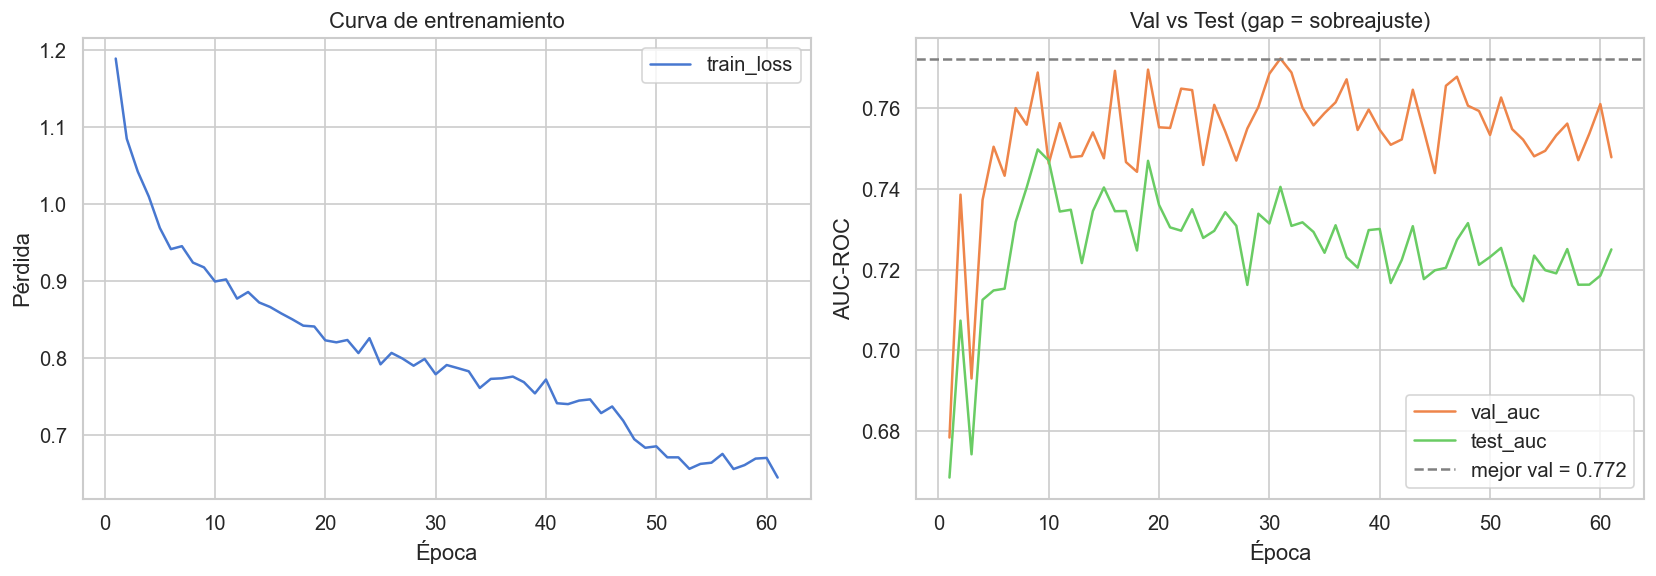

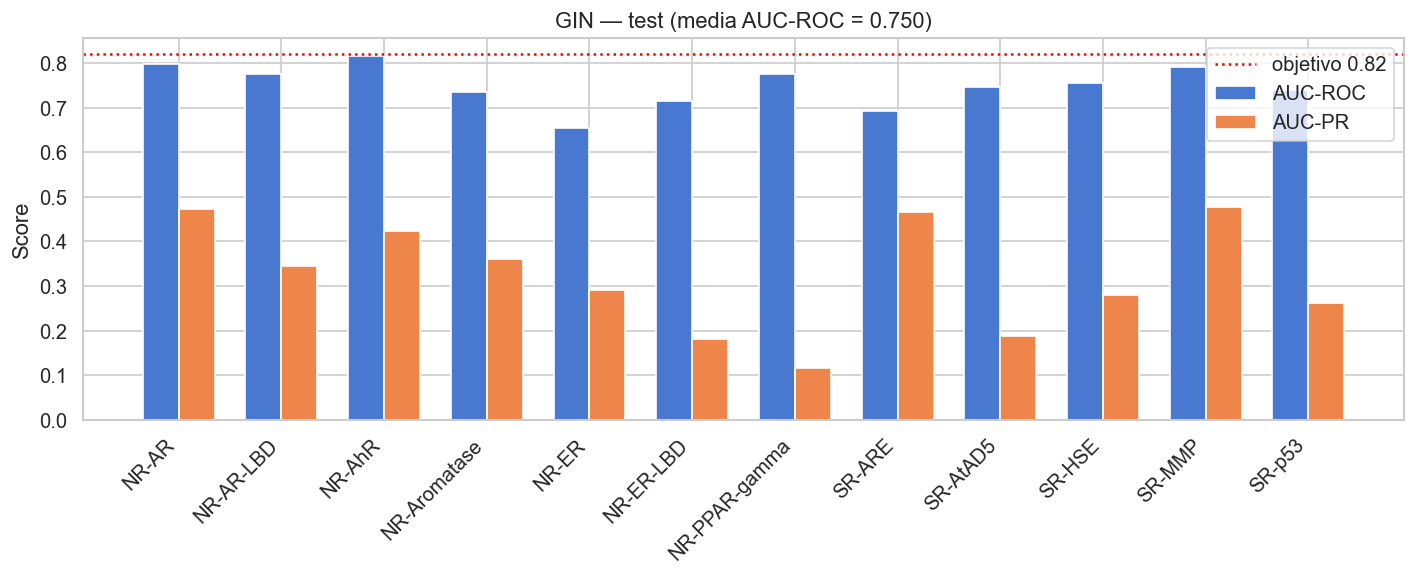

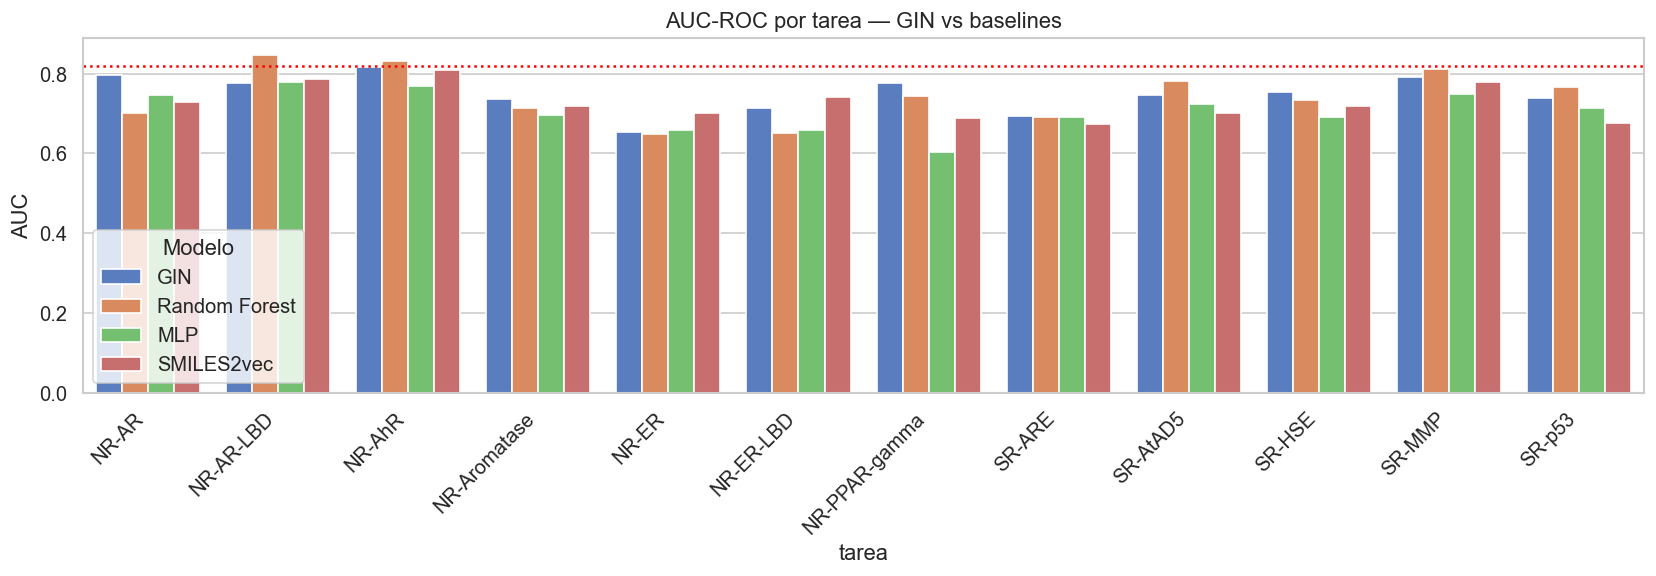

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(hist_df) > 0:
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Pérdida")
    axes[0].set_title("Curva de entrenamiento")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="C1", label="val_auc")
    if "test_auc" in hist_df.columns:
        axes[1].plot(hist_df["epoch"], hist_df["test_auc"], color="C2", label="test_auc")
    axes[1].axhline(best_val, color="gray", ls="--", label=f"mejor val = {best_val:.3f}")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC-ROC")
    axes[1].set_title("Val vs Test (gap = sobreajuste)")
    axes[1].legend()
else:
    for ax in axes:
        ax.text(0.5, 0.5, "Sin historial (SKIP_TRAINING)", ha="center", va="center")

plt.tight_layout()
fig.savefig(FIG_DIR / "training_curves.png", bbox_inches="tight")
plt.show()

# AUC por tarea — GIN test
auc_plot_df = metrics_df[metrics_df["split"] == "test"].copy()
plt.figure(figsize=(12, 5))
x = np.arange(len(TASK_NAMES))
w = 0.35
plt.bar(x - w / 2, auc_plot_df["AUC_ROC"], width=w, label="AUC-ROC")
plt.bar(x + w / 2, auc_plot_df["AUC_PR"], width=w, label="AUC-PR")
plt.xticks(x, TASK_NAMES, rotation=45, ha="right")
plt.axhline(0.82, color="red", ls=":", label="objetivo 0.82")
plt.ylabel("Score")
plt.title(f"GIN — test (media AUC-ROC = {mean_test:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "gin_metrics_per_task.png", bbox_inches="tight")
plt.show()

# Comparación multi-modelo
if len(comparison_df) > 1:
    melt = comparison_df.melt(id_vars="Modelo", value_vars=TASK_NAMES, var_name="tarea", value_name="AUC")
    plt.figure(figsize=(14, 5))
    sns.barplot(data=melt, x="tarea", y="AUC", hue="Modelo")
    plt.xticks(rotation=45, ha="right")
    plt.axhline(0.82, color="red", ls=":")
    plt.title("AUC-ROC por tarea — GIN vs baselines")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "model_comparison.png", bbox_inches="tight")
    plt.show()

## 7. Curvas ROC (tareas seleccionadas)

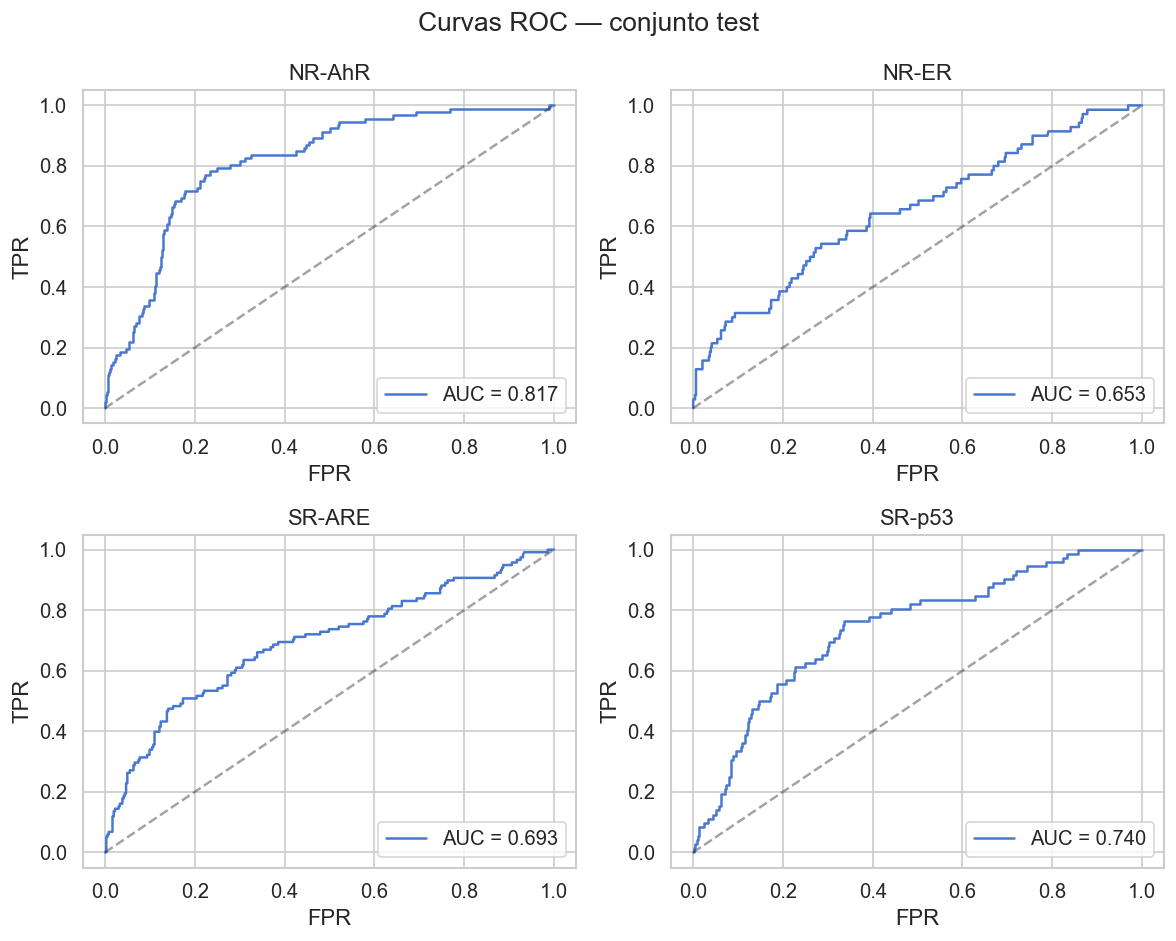

In [41]:
ROC_TASKS = ["NR-AhR", "NR-ER", "SR-ARE", "SR-p53"]
y_true, y_pred, mask = collect_predictions(model, test_loader, device)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, task in zip(axes, ROC_TASKS):
    t_idx = TASK_NAMES.index(task)
    valid = mask[:, t_idx].astype(bool)
    y_t = y_true[valid, t_idx]
    p_t = y_pred[valid, t_idx]
    if len(np.unique(y_t)) < 2:
        ax.set_title(f"{task} — no evaluable")
        continue
    fpr, tpr, _ = roc_curve(y_t, p_t)
    auc_val = auc_test.get(task, float("nan"))
    ax.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(task)
    ax.legend(loc="lower right")

plt.suptitle("Curvas ROC — conjunto test")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_test.png", bbox_inches="tight")
plt.show()

## 8. Veredicto

In [42]:
val_mean = metrics_df.loc[metrics_df["split"] == "val", "AUC_ROC"].mean()
gap = abs(val_mean - mean_test)

rf_row = comparison_df.loc[comparison_df["Modelo"] == "Random Forest"] if baseline_path.is_file() else pd.DataFrame()
beats_rf = bool(not rf_row.empty and mean_test > rf_row["Media AUC-ROC"].iloc[0])

checks = [
    ("AUC test >= 0.82 (objetivo)", mean_test >= 0.82),
    ("AUC test > RF baseline", beats_rf if baseline_path.is_file() else None),
    ("|val - test| < 0.02", gap < 0.02),
    ("Todas las tareas AUC > 0.75", all(v >= 0.75 for v in auc_test.values())),
]

verdict_df = pd.DataFrame(checks, columns=["criterio", "cumple"])
display(verdict_df)

print(f"\nResumen: val_AUC={best_val:.4f} | test_AUC={mean_test:.4f} | gap={gap:.4f}")
if mean_test >= 0.82:
    print("Objetivo principal alcanzado.")
elif mean_test >= 0.77:
    print("Supera RF; ajustar hiperparámetros para llegar a 0.82.")
else:
    print("[ALERTA] Rendimiento por debajo del RF — revisar datos o configuración.")

,criterio,cumple
0,AUC test >= 0.82 (objetivo),False
1,AUC test > RF baseline,True
2,|val - test| < 0.02,True
3,Todas las tareas AUC > 0.75,False



Resumen: val_AUC=0.7723 | test_AUC=0.7498 | gap=0.0191
[ALERTA] Rendimiento por debajo del RF — revisar datos o configuración.
